# Notebook 60: All HR tracks for final fiducial grid

In [6]:
# nb_id is used to identify this notebook's output files (i.e., figures) if there are any
# it should match 
# the first two digits in the notebook's title
nb_id = 60

## Imports

In [7]:
import numpy as np
np.where(np.linspace(1, 100, 20) > 45)

(array([ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),)

In [8]:
from pathlib import Path
from math import isnan, nan

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm, to_rgba
from matplotlib.lines import Line2D

import astropy.units as u
import astropy.constants as ct
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

import mesa_reader as mr
import mesaPlot as mp
#import tulips as tp

import sys
sys.path.append('..')
from src.star import fix_unit
from src.binary import a_from_p, p_from_a, eggleton_rl1_radius, marchant_l2_radius
from src.util import DATA_DIR, MESA_DATA_DIR

plt.style.use('./plotstyle.mplstyle')

/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <

In [9]:
FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

In [10]:
plt.style.use('./plotstyle.mplstyle')

## Definitions

### Constants

In [11]:
Z_SUN = 0.017

### Utilities

In [12]:
stage_index = dict(zams=6, prezams=7)

In [13]:
def savefig(fig, fname):
    """Saves png, pdf and eps figure files to a nb-specific folder."""
    fname = f'nb{nb_id}_{fname}'
    plt.savefig(FIGURE_FOLDER/(fname+'.png'), bbox_inches='tight')
    plt.savefig(FIGURE_FOLDER/(fname+'.pdf'), bbox_inches='tight')
    plt.savefig(FIGURE_FOLDER/(fname+'.eps'), bbox_inches='tight')

In [14]:
def normarr(arr):
    return (arr-min(arr))/(max(arr)-min(arr))

In [15]:
def get_model_folder(model_id, verbose=True):
    """Finds model folder given its id."""
    matches = list(PROJECT_FOLDER.glob(f'{model_id}*'))
    
    if len(matches) > 1:
        if verbose:
            print('\n'.join((
                f'Multiple matches for id {model_id} found in {PROJECT_FOLDER}:',
                *[str(match) for match in matches]
            )))
        return
    elif len(matches) != 0:
        match = matches[0]
        if verbose:
            print(f'Found match {match}')
        return match
    else:
        if verbose:
            print(f'No matches found in {PROJECT_FOLDER}')
        return           

In [16]:
def get_model_dict(grid_folder):
    """Given a model folder, loads the paths of specific stars into a 
    m1, p_orb dictionary."""
    d = dict()
    for model_folder in grid_folder.glob('m*_p*_w*'):
        if model_folder.suffix == '.log':
            continue
        m, p, w = model_folder.name.replace('d', 'e').split('_')
        w = float(w.lstrip('w'))
        p = f'{float(p.lstrip("p")):.2f}'      
        m = f'{float(m.lstrip("m")):.1f}'
        
        if m not in d.keys():
            d[m] = dict()
        d[m][p] = model_folder
    return d

In [17]:
def mesareader_operator(expression, object_to_call='h'):
    """Converts strings into operations between mesareader columns.
    
    Supports summation, subtraction, multiplication, division and exp10."""
    operations = ['+', '-', '*', '/', '^', 'E', '(', ')', ',']
    
    mr_expression = ''
    attr = ''
    char_i = 0
    while char_i < len(expression):
        char = expression[char_i]
        if char not in operations:
            mr_expression += f'{object_to_call}.__getattr__("{char}'
        else:
            if char == '^':
                char = '10**'
            elif char == 'E':
                char = 'gamma_e('
            mr_expression += f'{char}{object_to_call}.__getattr__("'
        char_i += 1
        char = expression[char_i]
        while char not in operations+['']:
            attr += char
            char_i += 1
            try:
                char = expression[char_i]
            except IndexError:
                char = ''
        if char == '^':
            char = '10**'
        elif char == 'E':
                char = 'gamma_e('
        attr = f'{attr}"){char}'
        mr_expression += attr
        attr = ''
        char_i += 1
            
    return mr_expression


### Plotting

In [18]:
def history_plot(ax, model_dict_list, model_styles, x, y, invert_xaxis, invert_yaxis, title=False,
                 label_period=True, period_mask=None):
    """2D line plot for all m1, p_orb combinations from a given model.
    
    Assumes a single m1 per dict.
    """
    
    #base_dict = model_dict_list[0]
    #all_paths = [base_dict[k1][k2] for k1 in base_dict.keys() for k2 in base_dict[k1].keys()] 
    
    all_periods = []
    for dict_ in model_dict_list:
        for k1 in dict_.keys():
            for k2 in dict_[k1].keys():
                all_periods.append(k2)
    all_periods = np.unique(all_periods)
    all_periods = all_periods[np.argsort([float(p) for p in all_periods])]
    
    if period_mask is not None:
        all_periods = all_periods[period_mask]
    
    period_color_dict = {}
    for i, p in enumerate(all_periods):
        period_color_dict[p] = cm.jet(i/len(all_periods))
    
    handles = []
    for p_key in all_periods:
        p = float(p_key)
        c = period_color_dict[p_key]
        
        if label_period:
            label = f'${p:.2f}\\,\\mathrm{{d}}$'
        else:
            label = None
        handles.append(Line2D([], [], ls='-', color=c, label=label))
               
        for dict_, ls in zip(model_dict_list, model_styles):
            dict_ = dict_[list(dict_.keys())[0]]
            try:
                model_path = dict_[p_key]
                h = mr.MesaData(str(model_path/'LOGS/history.data'))
            except:
                print(f'Model {model_path} failed to load.')
                continue
            else:
                x_data = eval(mesareader_operator(x))
                y_data = eval(mesareader_operator(y))
                ax.plot(x_data, y_data, ls=ls, color=c, lw=1)
                
    if invert_xaxis:
        ax.invert_xaxis()
    if invert_yaxis:
        ax.invert_yaxis()
    
    if label_period:
        ax.legend(handles=handles, frameon=False, loc='upper left', bbox_to_anchor=(1, 1), ncol=2)
    
    return ax, handles

## HR diagram

In [19]:
def log_l_const_rad(log_teff, r):
    teff = 10.**log_teff * u.K
    r = fix_unit(r, u.Rsun)
    log_l = np.log10(4*np.pi*ct.sigma_sb * teff**4 * r**2 / u.Lsun)
    return log_l
log_l_const_rad = np.vectorize(log_l_const_rad)

In [20]:
import numpy as np
np.log10(6.e5)

5.778151250383644

In [21]:
def hd_limit(log_teff):
    teff = 10**log_teff * u.K
    log_l = (
        np.log10(1.e5*np.sqrt(4*np.pi))
        + 0.5*np.log10(ct.sigma_sb * u.Rsun**2 * teff**4 / u.Lsun)
    ).value
    log_l = max(log_l, np.log10(6.e5))
    return log_l
hd_limit = np.vectorize(hd_limit)

In [22]:
def hr_diagram_tracks(
    ax,
    model_dicts,
    models_to_plot,
    model_style_list,
    xlim=None, 
    ylim=None,
    legend=True,
    labelx=True, 
    labely=True,
    period_mask=None
    ):
    model_dict_list = [{models_to_plot: model_dicts[models_to_plot]}]
    
    settings = dict(
        x='log_Teff',
        y='log_L',
        invert_xaxis=True,
        invert_yaxis=False,
        model_dict_list=model_dict_list,
        model_styles=model_style_list,
        label_period=legend,
        period_mask=period_mask
        )

    ax, handles = history_plot(ax, **settings)

    if labelx:
        ax.set_xlabel('$\\log T_\\mathrm{eff}/\\mathrm{K}$')
    if labely:
        ax.set_ylabel('$\\log L/\\mathrm{L}_\\odot$')

    # GUIDELINES
    
    if xlim is None:
        xlim = ax.get_xlim()
    if ylim is None:
        ylim = ax.get_ylim()

    ## Humphreys-Davidson limit and LBV regime
    hd_x = np.linspace(*xlim, 100)
    hd_y = hd_limit(hd_x)
    ax.plot(hd_x, hd_y, 'k--', lw=1)
    ax.fill_between(hd_x, hd_y, [ylim[1]]*len(hd_y), color='k', alpha=0.05)

    ## Lines of constant radius
    r_to_plot = np.concatenate((np.arange(0.5, 1, 0.1), np.arange(1, 10, 1), np.arange(10, 40, 10)))
    for i, r in enumerate(r_to_plot):
        r_y = log_l_const_rad(hd_x, r)
        ax.plot(hd_x, r_y, 'k--', lw=0.5, alpha=0.5)
        
        # label every two lines
        if not i%2:
            rotation = -np.arctan((r_y[10]-r_y[0])/(hd_x[10]-hd_x[0]))/np.pi*180       
            r_y_ = r_y[(hd_x >= xlim[1]) & (hd_x <= xlim[0])]
            y = r_y_[np.argmin(np.abs(r_y_-ylim[1]))]     
            x = hd_x[np.argmin(np.abs(r_y-y))]
            if (x < max(xlim) and x > min(xlim)) and (y < max(ylim) and y > min(ylim)):
                ax.text(
                    x, 
                    y,
                    f'${r:.1f}\\,\\mathrm{{R}}_\\odot$',
                    rotation=rotation,
                    ha='left',
                    va='top', 
                    fontsize=6,
                    alpha=0.8
                    )
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
        
    return ax, handles

In [23]:
def density_temperature_diagram_tracks(
    ax,
    models_to_plot,
    model_style_list,
    xlim, 
    ylim,
    legend=True,
    labelx=True, 
    labely=True
    ):
    model_dict_list = model_dicts[models_to_plot]
    model_label_list = model_labels[models_to_plot]
    
    settings = dict(
        x='log_center_Rho',
        y='log_center_T',
        invert_xaxis=False,
        invert_yaxis=False,
        model_dict_list=model_dict_list,
        model_styles=model_style_list,
        model_labels=model_label_list,
        label_period=legend
        )

    ax = history_plot(ax, **settings)

    if labelx:
        ax.set_xlabel('$\\log \\rho_\\mathrm{c}/\\mathrm{g}\\,\\mathrm{cm}^{-3}$')
    if labely:
        ax.set_ylabel('$\\log T_\\mathrm{c}/\\mathrm{K}$')

    # GUIDELINES
    
    if xlim is None:
        xlim = ax.get_xlim()
    if ylim is None:
        ylim = ax.get_ylim()

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    return ax

In [24]:
def old_e_scattering_edd_l(m):
    m = fix_unit(m, u.Msun)
    k = 0.4 * u.cm**2 /u.g
    l = 4*np.pi*ct.c*ct.G*m/k
    l = l.to(u.Lsun)
    return l.value

In [25]:
def gamma_e(m, l, x):
    m = fix_unit(m, u.Msun).value
    l = fix_unit(l, u.Lsun).value
    return 10.**-4.813 * (1+x) * l/m

In [26]:
def hre_diagram_tracks(
    ax,
    models_to_plot,
    model_style_list,
    xlim, 
    ylim,
    legend=True,
    labelx=True, 
    labely=True
    ):
    model_dict_list = model_dicts[models_to_plot]
    model_label_list = model_labels[models_to_plot]
    
    settings = dict(
        x='log_Teff',
        #y='^log_L/Estar_mass)',
        y='Estar_mass,^log_L,surface_h1)',
        invert_xaxis=True,
        invert_yaxis=False,
        model_dict_list=model_dict_list,
        model_styles=model_style_list,
        model_labels=model_label_list,
        label_period=legend
        )

    ax, handles = history_plot(ax, **settings)

    if labelx:
        ax.set_xlabel('$\\log T_\\mathrm{eff}/\\mathrm{K}$')
    if labely:
        ax.set_ylabel('$\\Gamma_\\mathrm{e}$')
    
    if xlim is not None:    
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    return ax, handles

In [27]:
def set_mcores(sample):
    for i, star in enumerate(sample):
        r = star[2]
        isof = is_of(r=r, m=star[0], p=star[1], q=1, kind='L2')
        if isof:
            mcore = nan
        else:
            mcore = l2_mzams_mcore_interpolator(star[0], star[1])
        sample[i, 3] = mcore
    return sample

In [28]:
def draw_mass_sample(
    res=int(1e8),
    min_m=20,
    max_m=300,
    min_p=0.1,
    max_p=4,
    min_mfinal=20,
    max_mfinal=50,
    mfinal_bin_width=0.2
):
    sample_masses = np.linspace(min_m, max_m, res)
    sample_probs = sample_masses**-2.3/np.sum(sample_masses**-2.3)
    sample_masses = np.random.choice(sample_masses, p=sample_probs, size=int(res/100))

    sample_periods = np.linspace(np.log10(min_p), np.log10(max_p), res)
    sample_probs = np.ones(res)/res
    sample_periods = 10.**np.random.choice(sample_periods, p=sample_probs, size=int(res/100))

    sample_zams_rs = np.array([l2_mzams_rzams_interpolator(m, p) for m, p in zip(sample_masses, sample_periods)])

    sample_mcores = np.zeros(int(res/100))

    sample_ = np.array([sample_masses, sample_periods, sample_zams_rs, sample_mcores]).T
    zams_l2of_sample = set_mcores(sample_).copy()
    
    mass_draw = zams_l2of_sample[:, 3]
    mass_draw = mass_draw[~np.isnan(mass_draw)]

    bins = np.arange(min_mfinal, max_mfinal+mfinal_bin_width, mfinal_bin_width)
    hist, bins = np.histogram(mass_draw, density=True, bins=bins)
    centers = np.array([(bin0+bin1)/2 for bin0, bin1 in zip(bins[:-1], bins[1:])])
    mode = centers[np.argmax(hist)]
    
    return zams_l2of_sample, mode

### Final properties

In [29]:
def get_core_mass_spin_w(logs, iso):
    central_iso_arr = [logs.profile_data(profile_number=n).__getattr__(iso)[-1] for n in logs.profile_numbers]
    max_iso_i = np.argmax(central_iso_arr)
    core_prof = logs.profile_data(profile_number=logs.profile_numbers[max_iso_i])
    core_edge_index = np.where(np.abs(core_prof.__getattr__(iso)-core_prof.__getattr__(iso)[-1]) <= 0.01)[0][0]
    core_mass = core_prof.mass[core_edge_index]
    core_am = 10**core_prof.log_J_inside[core_edge_index]
    core_w = core_prof.omega[core_edge_index]
    core_spin = (ct.c.cgs * core_am * u.g*u.cm**2/u.s / (ct.G.cgs * (core_mass * ct.M_sun.cgs)**2 )).to(u.dimensionless_unscaled).value
    return core_mass, core_spin, core_w

In [30]:
def edd_gamma(x, l, m):
    return 10**-4.813 * (1+x) * l/m


# Analysis

In [31]:
def load_models(project_folder):
    model_folders = list(project_folder.glob('*_md*_m*_zsundiv*_*y0_*dy'))
    _model_dicts = np.array([get_model_dict(folder) for folder in model_folders])
    model_dicts = dict()
    for dicts in _model_dicts:
        for m in dicts.keys():
            if m not in model_dicts.keys():
                model_dicts[m] = dicts[m]
    return model_dicts

In [32]:
model_ids = np.arange(0, 9, 1)
model_ids = np.array([f'{id:04d}' for id in model_ids])

In [33]:
PROJECT_BASE = MESA_DATA_DIR / '00_fiducial'

# Each entry: { label used in all_model_dicts : (variable suffix, folder name) }
metallicity_map = {
  #  '0.0005': ('0005zsun', '0000_ZdivZsun_5d-03'),
  #  '0.001':  ('001zsun',  '0001_ZdivZsun_1d-02'),
    '0.002':  ('002zsun',  '0002_ZdivZsun_2d-02'),
    '0.004':  ('004zsun',  '0003_ZdivZsun_4d-02'),
    '0.008':  ('008zsun',  '0004_ZdivZsun_8d-02'),
    '0.01':   ('01zsun',   '0005_ZdivZsun_1d-01'),
    '0.02':   ('02zsun',   '0006_ZdivZsun_2d-01'),
    '0.03':   ('03zsun',   '0007_ZdivZsun_3d-01'),
    '0.04':   ('04zsun',   '0008_ZdivZsun_4d-01'),
}

# initialize container for final dict
all_model_dicts = {}

for z_label, (suffix, folder_name) in metallicity_map.items():
    PROJECT_FOLDER = PROJECT_BASE / folder_name

    model_ids = np.arange(1, 25, 1)
    model_ids = np.array([f'{id:03d}' for id in model_ids])
    model_folders = np.array([get_model_folder(id) for id in model_ids])
    model_dicts = np.array([get_model_dict(folder) for folder in model_folders])
    model_labels = np.array([f'${float(id):0f}\\,\\mathrm{{M}}_\\odot$' for id in model_ids])

    # create a variable named model_dicts_XXXzsun dynamically
    globals()[f'model_dicts_{suffix}'] = model_dicts

    # add entry to final dict (same structure as before)
    all_model_dicts[z_label] = {
    k: v
    for d in model_dicts
    for k, v in d.items()
}



Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/001_m10
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/002_m15
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/003_m20
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/004_m25
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/005_m30
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/006_m35
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/007_m40
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/008_m45
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/009_m50
Found match /mnt/ceph/users/ldesa/mesa_che_grids/sse_production/

In [34]:
import pandas as pd

In [35]:
final_core_prop_array_dict = {
    '0.0005': np.load(DATA_DIR/'09_enhanced_w_core_props.npy'),
    '0.005': np.load(DATA_DIR/'08_enhanced_w_core_props.npy'),
    '0.02': np.load(DATA_DIR/'07_enhanced_w_core_props.npy'),
    '0.05': np.load(DATA_DIR/'06_enhanced_w_core_props.npy'),
    '0.1': np.load(DATA_DIR/'00_enhanced_w_core_props.npy'),
    '0.2': np.load(DATA_DIR/'01_enhanced_w_core_props.npy'),
    '0.4': np.load(DATA_DIR/'02_enhanced_w_core_props.npy'),
    '0.6': np.load(DATA_DIR/'03_enhanced_w_core_props.npy'),
    '0.8': np.load(DATA_DIR/'04_enhanced_w_core_props.npy'),
    '1.0': np.load(DATA_DIR/'05_enhanced_w_core_props.npy')
}
core_props_df = pd.read_hdf(DATA_DIR/'00_fiducial_core_props_df.h5')

In [36]:
core_props_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6720 entries, 0 to 6719
Data columns (total 99 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   z_key                 6720 non-null   object 
 1   m_zams                6720 non-null   float64
 2   m_wr0                 1839 non-null   float64
 3   m_wr1                 1839 non-null   float64
 4   m_tams                1839 non-null   float64
 5   m_tahems              1839 non-null   float64
 6   m_cdepl               1839 non-null   float64
 7   m_odepl               1839 non-null   float64
 8   m_f                   1839 non-null   float64
 9   m_c_zams              1839 non-null   float64
 10  m_c_wr0               1839 non-null   float64
 11  m_c_wr1               1839 non-null   float64
 12  m_c_tams              1839 non-null   float64
 13  m_c_tahems            1839 non-null   float64
 14  m_c_cdepl             1839 non-null   float64
 15  m_c_odepl             1839

In [37]:
4%4

0

In [38]:
import math
import matplotlib.pyplot as plt
import numpy as np

def plot_hr_grid_for_metallicity(
    all_model_dicts,
    metallicity_label,
    masses,
    ncols=4,
    figsize=(16, 14),
    label_fontsize=18,
    mass_label_pos=(0.1, 0.1),
    save=True,
    padding=0.05,
    period_mask=None,
):
    """
    Plot a grid of HR diagrams for a given metallicity and list of masses.
    Two-pass:
      - pass 1: let hr_diagram_tracks choose limits, record them
      - pass 2: call hr_diagram_tracks with unified limits so its internal
                labels (HD line, R=const) are placed consistently.
    Synchronizes:
      - y-limits per row
      - x-limits per column (preserving reversed HR x-axis)
      - adds ±padding (default 0.05) in both x and y.
    """

    model_dicts = all_model_dicts[metallicity_label]

    nrows = math.ceil(len(masses) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(wspace=0, hspace=0)

    # ---------- PASS 1: probe auto limits ----------
    row_ylims = {r: [] for r in range(nrows)}
    col_xlims = {c: [] for c in range(ncols)}

    for i, mass in enumerate(masses):
        row, col = divmod(i, ncols)
        ax = axes[row, col]

        models_to_plot = str(mass)
        model_style_list = ['-']

        # Minimal call: we just want its auto xlim/ylim
        ax, _ = hr_diagram_tracks(
            ax=ax,
            model_dicts=model_dicts,
            models_to_plot=models_to_plot,
            model_style_list=model_style_list,
            legend=False,
            labelx=False,
            labely=False,
            period_mask=period_mask,
        )

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        row_ylims[row].append(ylim)
        col_xlims[col].append(xlim)

        # Clear so we can redraw cleanly with final limits in pass 2
        ax.cla()

    # Turn off unused axes (no mass assigned)
    for j in range(len(masses), nrows * ncols):
        row, col = divmod(j, ncols)
        axes[row, col].axis('off')

    # ---------- Compute unified limits with padding ----------

    # Y per row (normal orientation)
    final_ylims = {}
    for row in range(nrows):
        if not row_ylims[row]:
            continue
        ymins = [yl[0] for yl in row_ylims[row]]
        ymaxs = [yl[1] for yl in row_ylims[row]]
        ymin = min(ymins) - padding
        ymax = max(ymaxs) + padding
        final_ylims[row] = (ymin, ymax)

    # X per column (respect reversed HR axis if present)
    final_xlims = {}
    for col in range(ncols):
        if not col_xlims[col]:
            continue

        # Orientation from first panel in this column
        first_xlim = col_xlims[col][0]
        reversed_x = first_xlim[0] > first_xlim[1]

        lefts = [xl[0] for xl in col_xlims[col]]
        rights = [xl[1] for xl in col_xlims[col]]

        if reversed_x:
            # HR-style: left is hotter (numerically larger logTeff)
            left = max(lefts) + padding
            right = min(rights) - padding
            final_xlims[col] = (left, right)
        else:
            left = min(lefts) - padding
            right = max(rights) + padding
            final_xlims[col] = (left, right)

    # ---------- PASS 2: actual plotting with fixed limits ----------

    for i, mass in enumerate(masses):
        row, col = divmod(i, ncols)
        ax = axes[row, col]

        # Skip if something went wrong
        if row not in final_ylims or col not in final_xlims:
            ax.axis('off')
            continue

        # Mass label
        try:
            m_float = float(mass)
            m_label = f"{int(m_float)}"
        except ValueError:
            m_label = str(mass)

        models_to_plot = str(mass)
        model_style_list = ['-']

        legend = (i == ncols - 1)  # or whatever logic you prefer
        labelx = False
        labely = False

        ax, handles = hr_diagram_tracks(
            ax=ax,
            model_dicts=model_dicts,
            models_to_plot=models_to_plot,
            model_style_list=model_style_list,
            xlim=final_xlims[col],
            ylim=final_ylims[row],
            legend=legend,
            labelx=labelx,
            labely=labely,
            period_mask=period_mask,
        )

        ax.tick_params(direction='in')
        if col > 0:
            ax.set_yticklabels([])

        mx, my = mass_label_pos
        ax.text(
            mx, my,
            f'${m_label}\\,\\mathrm{{M}}_\\odot$',
            va='center', ha='left',
            transform=ax.transAxes,
            fontsize=label_fontsize,
        )

    # ---------- Global labels & save ----------

    fig.text(0.5, 0.07, '$\\log T_\\mathrm{eff}/\\mathrm{K}$', va='top', ha='center')
    fig.text(0.08, 0.5, '$\\log L/\\mathrm{L}_\\odot$', rotation=90, va='center', ha='right')
    fig.text(0.5, 0.9, f'${metallicity_label}\\,\\mathrm{{Z}}_\\odot$', va='bottom', ha='center')

    if save:
        savefig(fig, f'hr_allp_mass_comparison_{metallicity_label}Zsun')

    return fig, axes


In [39]:
all_masses = list(all_model_dicts['0.02'].keys())
all_masses

['10.0',
 '15.0',
 '20.0',
 '25.0',
 '30.0',
 '35.0',
 '40.0',
 '45.0',
 '50.0',
 '60.0',
 '70.0',
 '80.0',
 '90.0',
 '100.0',
 '120.0',
 '140.0',
 '160.0',
 '180.0',
 '200.0',
 '220.0',
 '240.0',
 '260.0',
 '280.0',
 '300.0']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


(<Figure size 1600x1400 with 8 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

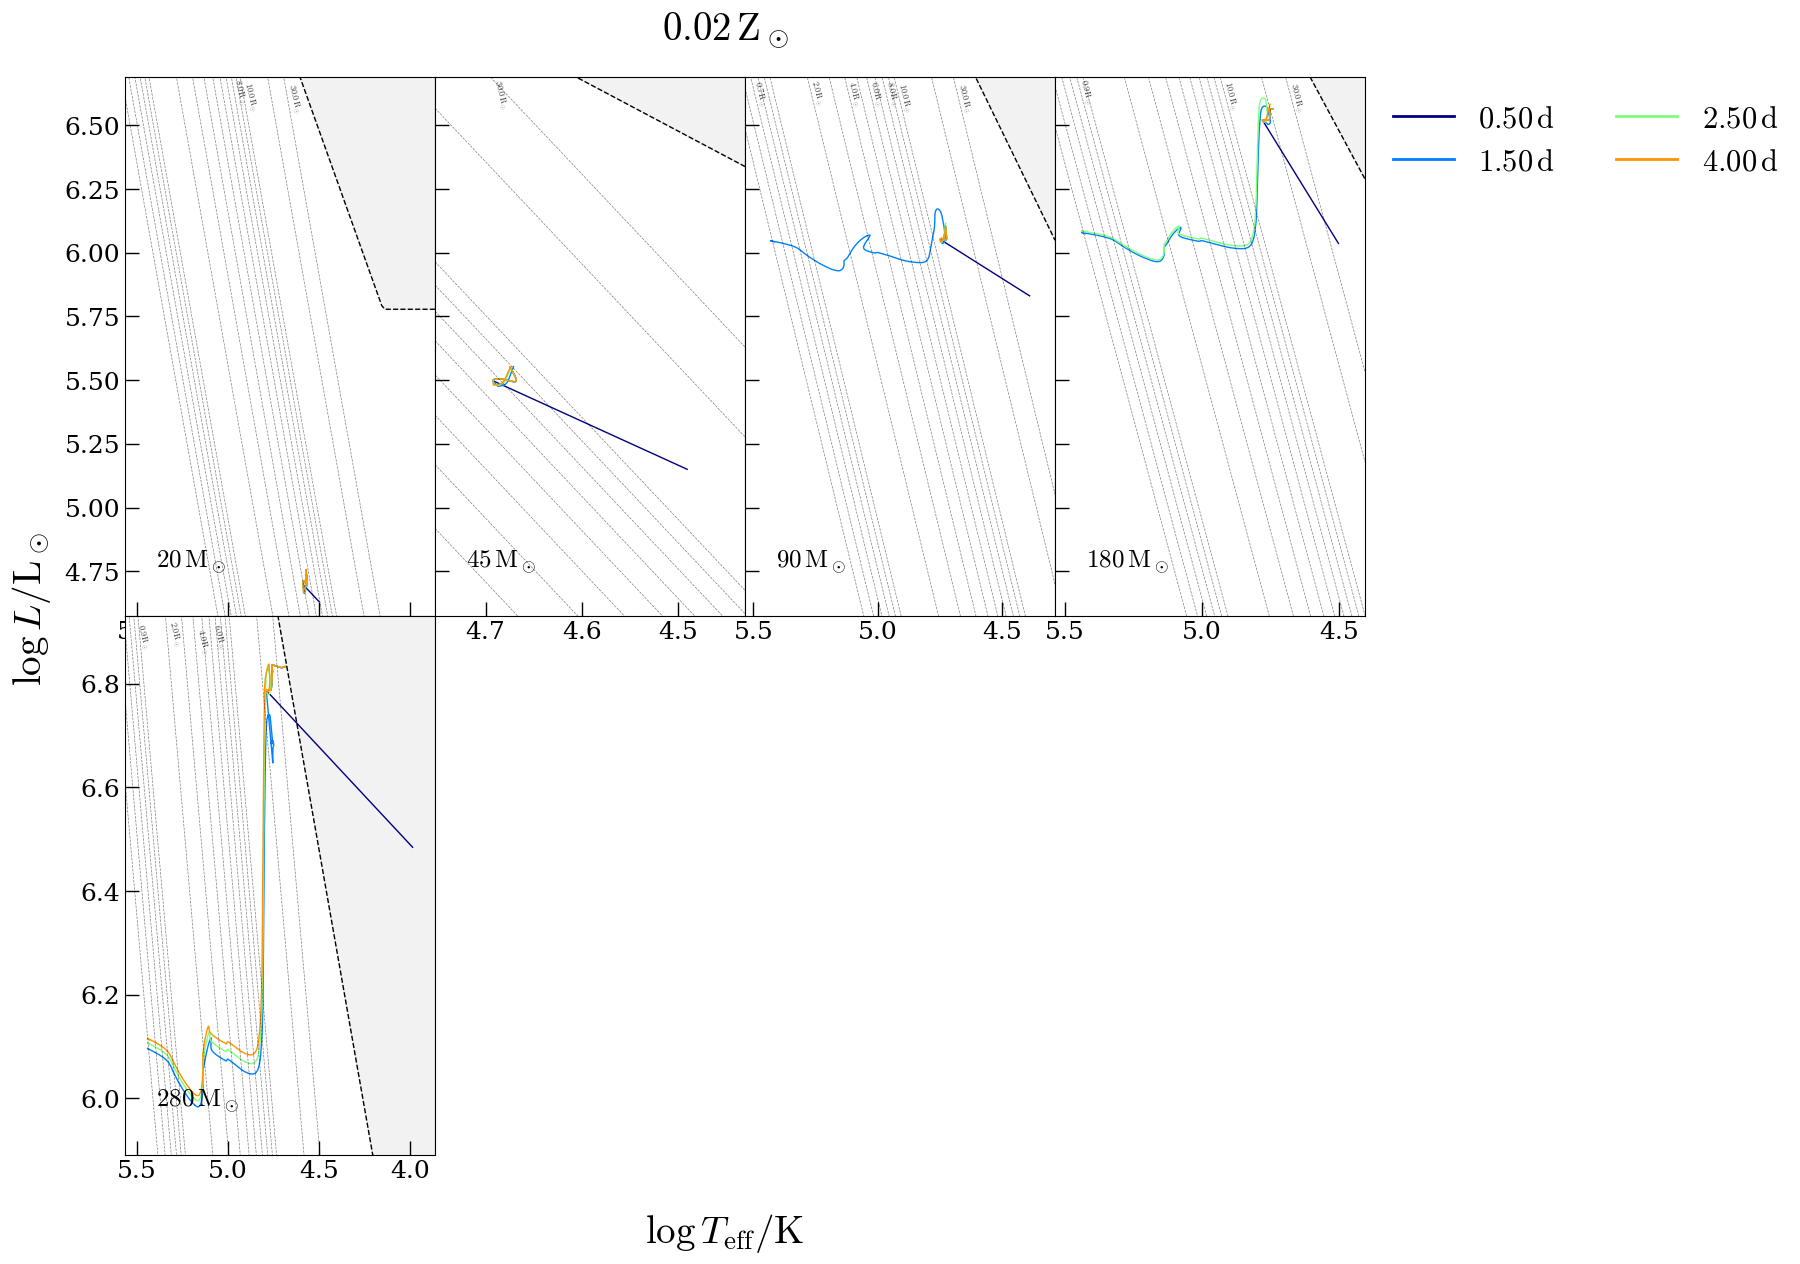

In [40]:
period_mask = np.zeros(40)
period_mask[np.arange(1, 41, 10)] = np.ones_like(np.arange(1, 41, 10))
period_mask = period_mask.astype(bool)

plot_hr_grid_for_metallicity(
    all_model_dicts=all_model_dicts,
    metallicity_label='0.02',
    masses=all_masses[2::5],
    period_mask=period_mask
    )